In [1]:
import warnings
import time

import pandas as pd
import numpy as np

import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.graph_objects as go

import lifelines
from lifelines.utils import concordance_index

import os

import tensorflow as tf
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

from scipy.stats import norm, t, probplot, pearsonr
from scipy.special import gamma

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

# import thetaflow as thf
import modelnn2 as thf

2026-03-21 01:23:41.409798: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774067021.428568   24120 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774067021.433786   24120 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774067021.448174   24120 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774067021.448201   24120 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774067021.448203   24120 computation_placer.cc:177] computation placer alr

In this notebook, we attempt to use thetaflow to replicate the exact structure used in Cox-nnet. An implementation for the Cox model, where the inputs are actually the outputs of a dense neural network.

In [2]:
# Count DSeq2 transformed matrix passed to the vsd in R
df_coxnnet_kirc = pd.read_csv("log_counts_kirc.csv", header = None)

# times = pd.read_csv("ytime_coxnnet.csv", header = None).iloc[:,0].to_numpy()
# delta = pd.read_csv("ystatus_coxnnet.csv", header = None).iloc[:,0].to_numpy()

print("Data dimensions: {}".format(df_coxnnet_kirc.shape))
df_coxnnet_kirc.head()

Data dimensions: (517, 19500)


,0,1,2,3,4,5,6,7,8,9,...,19490,19491,19492,19493,19494,19495,19496,19497,19498,19499
0,-0.591395,0.672267,-1.019161,-1.672059,-0.479418,-1.040106,-0.11062,-1.204243,-1.084686,0.228324,...,-1.702740,-1.906983,-2.164082,0.328562,-1.940324,-0.843944,-1.472628,-1.760932,-0.402279,-0.344267
1,-0.591395,-1.179125,-1.582692,0.838075,-0.022309,0.525567,-0.11062,-0.108385,0.317944,-0.645397,...,-0.939731,-1.561306,-0.548214,-1.148819,-0.818804,-0.864956,-0.017958,0.033100,1.349957,-0.344267
2,-0.437130,0.518018,-0.778402,-1.023351,-0.169857,0.935554,-0.11062,-0.108385,-1.084686,1.201025,...,0.152828,-0.173846,-1.775287,-1.333401,-0.400217,-1.309979,-0.668346,0.180228,-0.994432,-0.344267
3,-0.773851,-0.217862,0.078533,-0.963403,-0.079721,1.253564,-0.11062,0.583024,0.317944,0.643141,...,-0.087866,0.074576,-0.073961,0.000807,-0.179123,-0.147044,-0.533847,-0.203854,-0.144667,-0.344267
4,0.325574,-0.712502,-0.024271,-0.262327,0.978589,0.525567,-0.11062,0.987472,4.204973,-0.468218,...,-0.048902,-0.206010,0.614476,-1.333401,-0.082739,0.265071,0.438234,0.286619,-1.049497,-0.344267


In [3]:
df_log = pd.read_csv("tcga_brca_count_data_coxnnet.csv")
df = pd.read_csv("tcga_brca_count_data.csv")

X = df.iloc[:,2:]
X_log = df_log.iloc[:,2:]
X_coxnnet = df_coxnnet_kirc

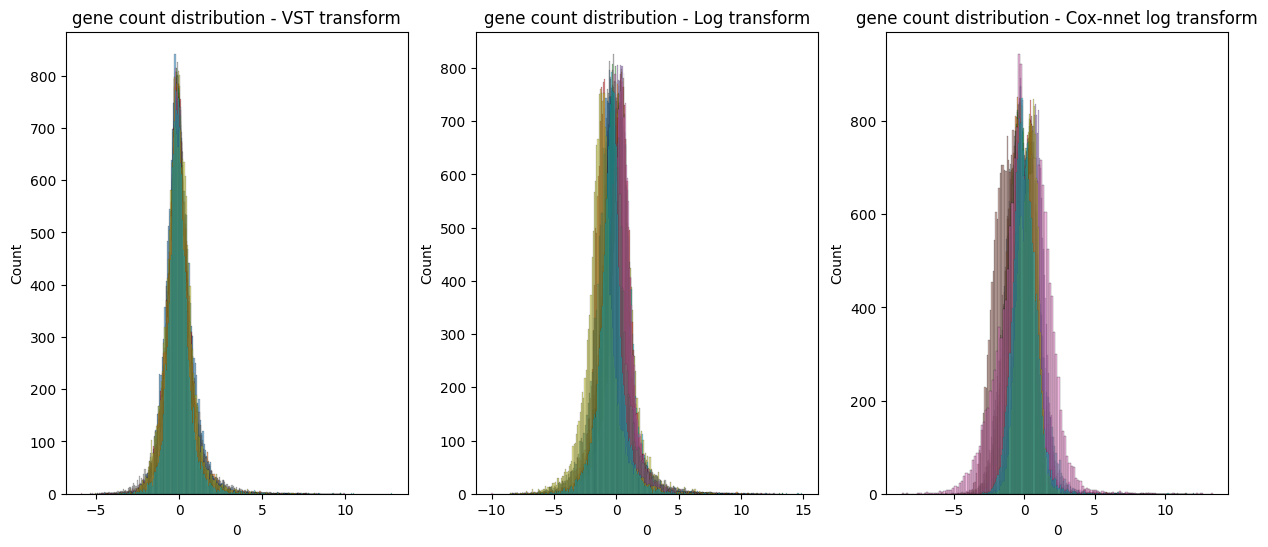

In [4]:
fig, ax = plt.subplots(nrows = 1, ncols = 3, figsize = (15,6))

for i in range(20):
    sns.histplot(X.iloc[i, :], ax = ax[0], alpha = 0.5)
    sns.histplot(X_log.iloc[i, :], ax = ax[1], alpha = 0.5)
    sns.histplot(X_coxnnet.iloc[i, :], ax = ax[2], alpha = 0.5)

ax[0].set_title("gene count distribution - VST transform")
ax[1].set_title("gene count distribution - Log transform")
ax[2].set_title("gene count distribution - Cox-nnet log transform")
plt.show()

Note that above we load two preprocessed datasets from the TCGA-BRCA database and one from the TCGA-KIRC database. The latter is the exact same dataset considered in the cox-nnet original paper. Here, we only load it to show the differences between the different preprocessing approaches. Certainly, the first one seems to be the most modern, with a Variance Stabilization Transform follower my a mean scaling. The second consists in simply taking the $log(x+1)$ where $x$ stands for the gene-count matrix. The last one is not much clear, but it consists of a similar processing than the second, according to the paper. We can see by the scales that both methods indeed appear to vary similarly.

We will be considering for the analysis in this dataset only the first dataset from the TCGA-BRCA database.

In [5]:
X = df.iloc[:,2:]

y = df["time"].to_numpy()/365
delta = df["delta"].to_numpy()
data = [tf.constant(y, shape = (len(y), 1), dtype = tf.float32), tf.constant(delta, shape = (len(delta), 1), dtype = tf.float32)]

In [6]:
X_train, X_test, y_train, y_test, delta_train, delta_test = train_test_split(X, y, delta, test_size = 0.2, random_state = 10)

X_train = tf.cast(X_train, dtype = tf.float32)
X_test = tf.cast(X_test, dtype = tf.float32)
data_train = [tf.constant(y_train, shape = (len(y_train), 1), dtype = tf.float32), tf.constant(delta_train, shape = (len(delta_train), 1), dtype = tf.float32)]
data_test = [tf.constant(y_test, shape = (len(y_test), 1), dtype = tf.float32), tf.constant(delta_test, shape = (len(delta_test), 1), dtype = tf.float32)]

In [7]:
def build_cox_nnet(dropout_rate = 0.1, ridge_penalty = 1.0e-2):
    cox_nnet_parameters = {
        "theta": {"link": tf.identity, "link_inv": tf.identity, "par_type": "nn", "shape": 1, "init": 0.0},
    }
    
    def partial_loglikelihood_loss(model, nn_output, data):
        # Unpack your data tuple
        X, y, delta = data
        theta = model.get_variable("theta", nn_output)
        
        # Shapes for broascasting
        y_col = tf.reshape(y, [-1, 1])
        y_row = tf.reshape(y, [1, -1])
        theta_col = tf.reshape(theta, [-1, 1])
        delta_col = tf.reshape(delta, [-1, 1])

        # Matrix form to replace the sum loop in the partial log-likelihoood
        R_matrix = tf.cast(y_row >= y_col, dtype = tf.float32)
        exp_theta = tf.math.exp(theta_col)
        risk_sum = tf.matmul(R_matrix, exp_theta)
        log_risk_sum = tf.math.log(risk_sum + 1e-7)
        
        pll = tf.reduce_sum( delta_col * (theta_col - log_risk_sum) )
        return -pll

    def neural_network(model, seed = None):
        initializer = initializers.GlorotNormal(seed = seed)
        ridge = tf.keras.regularizers.L2(l2 = ridge_penalty)
        
        # 1. The Hidden Layer (Feature Extractor)
        model.dense1 = layers.Dense(
            units = 132,
            activation = "tanh",     
            kernel_initializer = initializer,
            kernel_regularizer = ridge,
            use_bias = True,
            dtype = tf.float32, 
            name = "latent_representation"
        )
        
        # 2. The Dropout Layer
        model.dropout = layers.Dropout(rate = dropout_rate, seed = seed)
        
        # 3. The Cox Beta Layer (The brilliant realization)
        model.output_layer = layers.Dense(
            units = 1, 
            activation = None,
            use_bias = False,
            kernel_initializer = initializer,
            kernel_regularizer = ridge,
            dtype = tf.float32,
            name = "beta_coefficients"
        )
    
    def neural_network_call(model, x_input, training = False):
        x = model.dense1(x_input)
        x = model.dropout(x, training = training)
        return model.output_layer(x) # Returns the final theta scalar for each patient
    
    def neural_network_call_nolast(model, x_input):
        x = model.dense1(x_input)
        return x
    
    return cox_nnet_parameters, partial_loglikelihood_loss, neural_network, neural_network_call, neural_network_call_nolast

In [8]:
def train_eval_cox_nnet(X_train, data_train, cox_nnet_parameters, 
                        cox_nnet_partial_loglikelihood_loss, cox_nnet_neural_network, cox_nnet_network_call, cox_nnet_network_call_nolast,
                        epochs = 10000, shuffle = True, metrics_update_freq = 50,
                        fine_tune = False,
                        get_covariances = False,
                        validation = False, val_prop = 0.2,
                        optimizer_nn = optimizers.SGD(learning_rate = 0.1, momentum = 0.9, nesterov = True, clipnorm = 1.0),
                        train_batch_size = None, val_batch_size = None,
                        buffer_size = 4096, gradient_accumulation_steps = None,
                        early_stopping = True, early_stopping_tolerance = 1.0e-4, early_stopping_warmup = 500,
                        reduce_lr = True, reduce_lr_warmup = 10,
                        reduce_lr_factor = 0.9, reduce_lr_min_delta = 1.0e-4, reduce_lr_patience = 5,
                        reduce_lr_cooldown = 20, reduce_lr_min_lr = 1e-5,
                        deterministic = True,
                        verbose = 1, print_freq = 50):
    """
        Get data and configuration and trains a completely new cox-nnet model and returns it.
    """
    cox_nnet_model = thf.ModelNN(cox_nnet_parameters, cox_nnet_partial_loglikelihood_loss,
                                 cox_nnet_neural_network, cox_nnet_network_call,
                                 cox_nnet_network_call_nolast, input_dim = (None, X_train.shape[1]), seed = 10)
    cox_nnet_model.pre_train_model(X_train, data_train,
                                   epochs = 1000, shuffle = True,
                                   optimizer_nn = optimizers.Adam(learning_rate = 0.1),
                                   verbose = 1, track_time = True)
    cox_nnet_model.train_model(X_train, data_train,
                               epochs = epochs, shuffle = shuffle, metrics_update_freq = metrics_update_freq,
                               fine_tune = fine_tune,
                               get_covariances = get_covariances,
                               validation = validation, val_prop = val_prop,
                               optimizer_nn = optimizer_nn,
                               train_batch_size = train_batch_size, val_batch_size = val_batch_size,
                               buffer_size = buffer_size, gradient_accumulation_steps = gradient_accumulation_steps,
                               early_stopping = early_stopping, early_stopping_tolerance = early_stopping_tolerance, early_stopping_warmup = early_stopping_warmup,
                               reduce_lr = reduce_lr, reduce_lr_warmup = reduce_lr_warmup,
                               reduce_lr_factor = reduce_lr_factor, reduce_lr_min_delta = reduce_lr_min_delta, reduce_lr_patience = reduce_lr_patience,
                               reduce_lr_cooldown = reduce_lr_cooldown, reduce_lr_min_lr = reduce_lr_min_lr,
                               deterministic = deterministic,
                               verbose = verbose, print_freq = print_freq)
    return cox_nnet_model

In [9]:
cox_nnet_parameters, \
cox_nnet_partial_loglikelihood_loss, \
cox_nnet_neural_network, \
cox_nnet_network_call, \
cox_nnet_network_call_nolast = build_cox_nnet(dropout_rate = 0.1, ridge_penalty = 1.0e-2)

with tf.device("/GPU:0"):
    model_nesterov = train_eval_cox_nnet(X_train, data_train, cox_nnet_parameters,
                                        cox_nnet_partial_loglikelihood_loss, cox_nnet_neural_network, cox_nnet_network_call, cox_nnet_network_call_nolast,
                                        optimizer_nn = optimizers.SGD(learning_rate = 0.1, momentum = 0.9, nesterov = True, clipnorm = 1.0),
                                        verbose = True)
    model_rmsprop = train_eval_cox_nnet(X_train, data_train, cox_nnet_parameters, 
                                       cox_nnet_partial_loglikelihood_loss, cox_nnet_neural_network, cox_nnet_network_call, cox_nnet_network_call_nolast,
                                       optimizer_nn = optimizers.RMSprop(learning_rate = 0.01, clipnorm = 1.0),
                                       verbose = True)
    model_adam = train_eval_cox_nnet(X_train, data_train, cox_nnet_parameters, 
                                    cox_nnet_partial_loglikelihood_loss, cox_nnet_neural_network, cox_nnet_network_call, cox_nnet_network_call_nolast,
                                    optimizer_nn = optimizers.Adam(learning_rate = 0.01, clipnorm = 1.0),
                                    verbose = True)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Optimizing... Epoch: [ 700 / 1000 ]  | Loss:  1.24938317e-08 | Param Dist:  0.000163805569 | Independent Learning rate:  0.001 | Network Learning rate:  0.1 | [Speed tracking disabled for determinism]   
Stopping. Model has converged at epoch 800
Optimizing... Epoch: [ 800 / 1000 ]  | Loss:  4.09713305e-11 | Param Dist:  6.63766832e-06 | Independent Learning rate:  0.001 | Network Learning rate:  0.1 | [Speed tracking disabled for determinism]   GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 9950 / 10000 ]  | Loss:  295.911774 | Param Dist:  1.19186604 | Independent Learning rate:  0.001 | Network Learning rate:  0.0531440899 | [Speed tracking disabled for determinism]    
Done.
Optimization finished in 112.739 seconds.

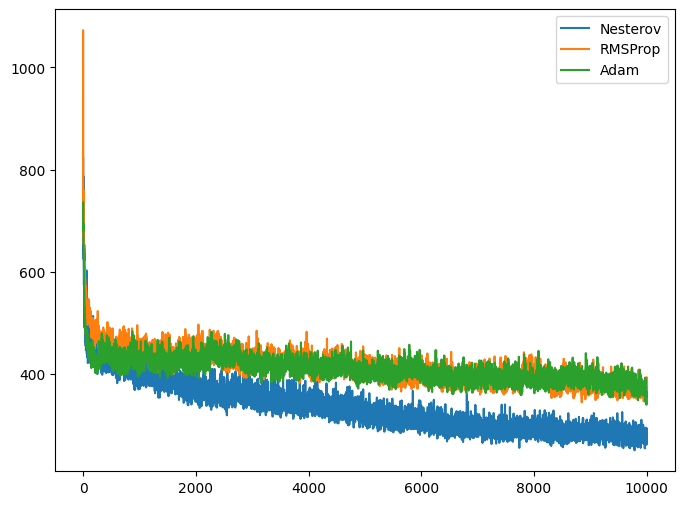

In [10]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

ax.plot(np.arange( model_nesterov.last_epoch+1 ), model_nesterov.loss_history.numpy(), label = "Nesterov")
ax.plot(np.arange( model_rmsprop.last_epoch+1 ), model_rmsprop.loss_history.numpy(), label = "RMSProp")
ax.plot(np.arange( model_adam.last_epoch+1 ), model_adam.loss_history.numpy(), label = "Adam")
ax.legend()

plt.show()

We can see that the SGD with Nesterov optimization performed better than the RMSProp and Adam proposals.

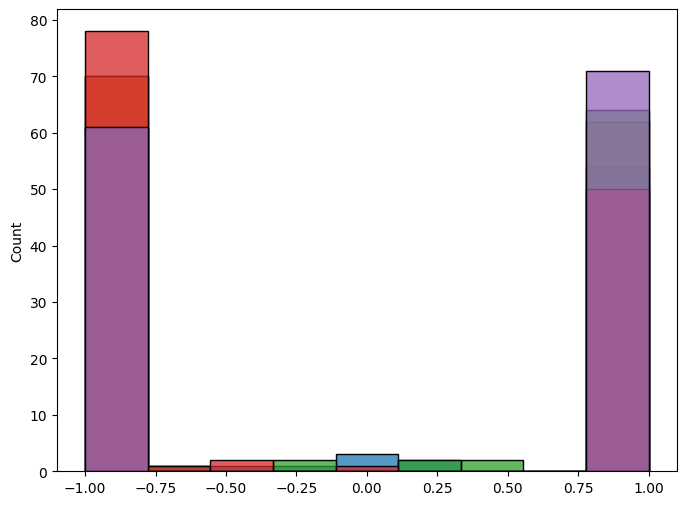

In [11]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

hidden_activations = cox_nnet_network_call_nolast(model_nesterov, X).numpy()
# Plot the hidden layer weights histogram for each of the first 5 patients
for i in range(5):
    sns.histplot(hidden_activations[i, :], ax = ax)

In the plot above, we can see the histograms for the activation values in the hidden layer for the first 5 patients in the dataset. Since the activation function is tanh, we can see that most of the network outputs saturate in 1 and -1 depending on the sign of that neuron's contribution to the final model.

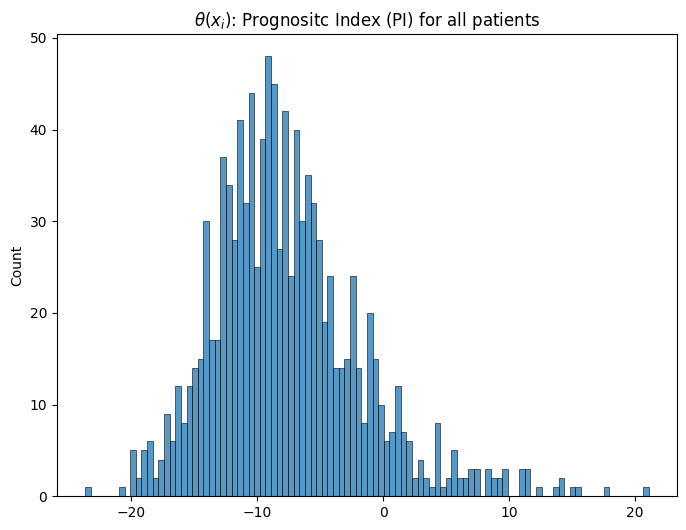

In [12]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

sns.histplot(x = model_nesterov.predict(X)["theta"].numpy().flatten(), bins = 100, ax = ax)
ax.set_title(r"$\theta(x_i)$: Prognositc Index (PI) for all patients")
plt.show()

In [13]:
theta_predictions = model_nesterov.predict(X_test)["theta"].numpy().flatten()

time_true = y_test
event_true = delta_test

c_index = concordance_index(
    event_times = time_true, 
    predicted_scores = -theta_predictions,
    event_observed = event_true
)

print(f"Harrell's C-index: {c_index:.4f}")

Harrell's C-index: 0.7390


As we can see above, the model is able to generalize quite well the predictions for a test set. Indeed, we obtained a C-index of around 0.73, suggesting that the model was able to discrminate patients lifetimes given their genomic expression profiles.

Before we can properly get the optimal hyperparameters, we will consider a longer training to check when does the model loss actually reaches a plateau. For that we will use the faster tested optimizer, which is the Nesterov SGD.

In [24]:
with tf.device("/GPU:0"):
    model_nesterov_longrun = train_eval_cox_nnet(X_train, data_train, cox_nnet_parameters,
                                                 cox_nnet_partial_loglikelihood_loss, cox_nnet_neural_network, cox_nnet_network_call, cox_nnet_network_call_nolast,
                                                 optimizer_nn = optimizers.SGD(learning_rate = 0.1, momentum = 0.9, nesterov = True, clipnorm = 1.0),
                                                 epochs = 25000, early_stopping_warmup = 1000,
                                                 verbose = True)

GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Optimizing... Epoch: [ 700 / 1000 ]  | Loss:  1.24938317e-08 | Param Dist:  0.000163805569 | Independent Learning rate:  0.001 | Network Learning rate:  0.1 | [Speed tracking disabled for determinism]   
Stopping. Model has converged at epoch 800
Optimizing... Epoch: [ 800 / 1000 ]  | Loss:  4.09713305e-11 | Param Dist:  6.63766832e-06 | Independent Learning rate:  0.001 | Network Learning rate:  0.1 | [Speed tracking disabled for determinism]   GPU detected. Activating GPU determinism. To reverse this, the Python environment (or kernel) must be restated.
Global seed set to 10.
Initializing training...
Optimizing... Epoch: [ 20550 / 25000 ]  | Loss:  236.079483 | Param Dist:  0.685646057 | Independent Learning rate:  0.001 | Network Learning rate:  0.0228767805 | [Speed tracking disabled for determinism]   
Stopping. Model has converged at epoch 20600
O

/tmp/ipykernel_24120/4139478568.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


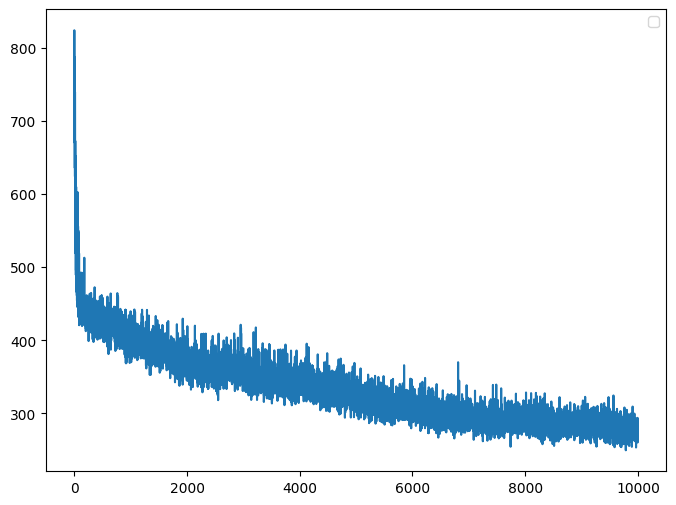

In [25]:
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,6))

ax.plot(np.arange( model_nesterov.last_epoch+1 ), model_nesterov.loss_history.numpy())
ax.legend()

plt.show()

/home/natan/.pyenv/versions/3.10.17/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


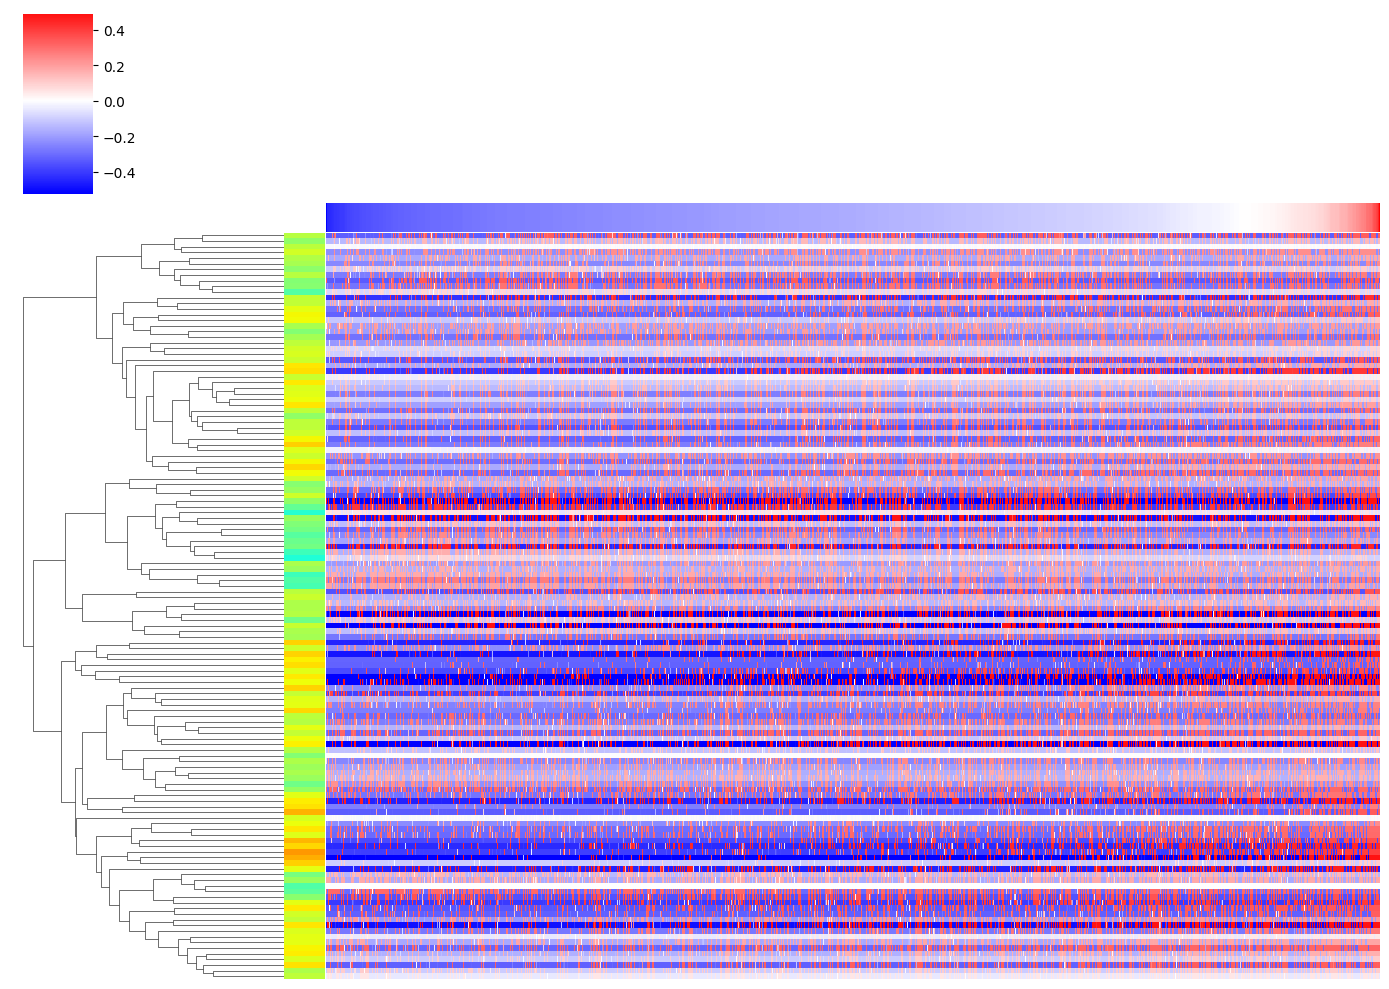

In [14]:
hidden_activations = cox_nnet_network_call_nolast(model_nesterov, X).numpy()
beta_weights = model_nesterov.output_layer.get_weights()[0].flatten()
theta_predictions = model_nesterov.predict(X)["theta"].numpy().flatten()

# Node Contributions (Weighted Activations)
contributions = hidden_activations * beta_weights 

# Sort Patients by Prognostic-Index (Theta)
patient_sort_idx = np.argsort(theta_predictions, axis = 0)
sorted_theta = theta_predictions[patient_sort_idx]
sorted_contributions = contributions[patient_sort_idx, :] 

# 4. Calculate the Pearson Correlation between each node's contribution and the PI
node_correlations = []
for k in range( len(beta_weights) ):
    corr, _ = pearsonr(contributions[:, k], theta_predictions)
    node_correlations.append(corr)
node_correlations = np.array(node_correlations)

# 5. Prepare DataFrames for Seaborn
# We transpose the matrix so Nodes are Rows (55) and Patients are Columns (N)
df_plot = pd.DataFrame(sorted_contributions.T)

# 6. Create Color Annotations for the Axes
# Create the top bar (Patient PI): Blue for low risk, Red for high risk
pi_norm = mcolors.Normalize(vmin = sorted_theta.min(), vmax = sorted_theta.max())
pi_cmap = plt.get_cmap('bwr')
col_colors = [pi_cmap(pi_norm(val)) for val in sorted_theta]

# Create the side bar (Node Correlation): Blue for negative, Red for positive correlation
corr_norm = mcolors.Normalize(vmin=-1, vmax=1)
corr_cmap = plt.get_cmap('jet') # The paper uses a rainbow-like colormap here
row_colors = [corr_cmap(corr_norm(val)) for val in node_correlations]

g = sns.clustermap(
    df_plot,
    cmap = "bwr",
    metric = "correlation",
    row_cluster = True,
    col_cluster = False,
    row_colors = row_colors,
    col_colors = col_colors,
    figsize = (14, 10),
    xticklabels = False,
    yticklabels = False,
    center = 0,
    robust = True
)

plt.show()

# Obtaining the optimal hyperparameters

In order to find the best dropout rates and the best ridge hyperparameter, we will perform a gridsearch with cross validation. Since this process is computationally heavy, we will not consider a very large grid.

In [32]:
from sklearn.model_selection import KFold
import itertools
import subprocess
import pickle

In [45]:
def call_grid_search_cox_nnet(X, y, delta, param_grid, n_splits = 5, epochs = 10000):
    # 1. Generate all combinations of hyperparameters
    keys = param_grid.keys()
    values = param_grid.values()
    param_combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    best_c_index = -np.inf
    best_params = None
    all_results = []

    print(f"Starting Grid Search: {len(param_combinations)} combinations.")
    print("-" * 50)

    # 2. Iterate over the combinations in the main process
    for params in param_combinations:
        print(f"Testing Parameters: {params}")
        
        # Pack the payload for THIS SPECIFIC combination
        payload = {
            "X": X,
            "y": y,
            "delta": delta,
            "params": params,       # Sending only one dictionary
            "n_splits": n_splits,
            "epochs": epochs
        }
        
        # Save payload to disk
        with open("grid_search_payload.pkl", "wb") as f:
            pickle.dump(payload, f)
            
        # Run the n_folds in a subprocess that will die upon finishing, freeing all the used VRAM In the process
        subprocess.run(["python3", "Kfold_cox_nnet.py"],
                       stdout = subprocess.DEVNULL,
                       stderr = subprocess.DEVNULL)

        # 4. Read the results back from the dead subprocess
        with open("grid_search_results.pkl", "rb") as f:
            result_data = pickle.load(f)
            
        avg_c_index = result_data["avg_c_index"]
        fold_c_indices = result_data["fold_c_indices"]
        
        print(f"-> Average C-index: {avg_c_index:.4f} | Folds: {[round(x, 4) for x in fold_c_indices]}\n")
        
        all_results.append({
            'params': params, 
            'avg_c_index': avg_c_index, 
            'fold_c_indices': fold_c_indices
        })
        
        # 5. Update the best configuration tracker
        if avg_c_index > best_c_index:
            best_c_index = avg_c_index
            best_params = params

    print("-" * 50)
    print(f"Best Parameters: {best_params}")
    print(f"Best Average C-index: {best_c_index:.4f}")
    
    return best_params, all_results

In [46]:
# param_grid = {
#     'dropout_rate': [0.0, 0.1, 0.2, 0.3],
#     'ridge_penalty': [1e-1, 1e-2, 1e-3, 1e-4]
# }
param_grid = {
    'dropout_rate': [0.0, 0.1],
    'ridge_penalty': [1e-2]
}


# --- Example Execution ---
best_params, all_results = call_grid_search_cox_nnet(X, y, delta, param_grid, n_splits = 5, epochs = 500)

Starting Grid Search: 2 combinations.
--------------------------------------------------
Testing Parameters: {'dropout_rate': 0.0, 'ridge_penalty': 0.01}
-> Average C-index: 0.6184 | Folds: [np.float64(0.6303), np.float64(0.5459), np.float64(0.6772), np.float64(0.626), np.float64(0.6127)]

Testing Parameters: {'dropout_rate': 0.1, 'ridge_penalty': 0.01}
-> Average C-index: 0.6428 | Folds: [np.float64(0.6353), np.float64(0.5914), np.float64(0.619), np.float64(0.7217), np.float64(0.6468)]

--------------------------------------------------
Best Parameters: {'dropout_rate': 0.1, 'ridge_penalty': 0.01}
Best Average C-index: 0.6428


In [47]:
# param_grid = {
#     'dropout_rate': [0.0, 0.1, 0.2, 0.3],
#     'ridge_penalty': [1e-1, 1e-2, 1e-3, 1e-4]
# }
param_grid = {
    'dropout_rate': [0.0],
    'ridge_penalty': [1e-2]
}


# --- Example Execution ---
best_params, all_results = call_grid_search_cox_nnet(X, y, delta, param_grid, n_splits = 5, epochs = 500)

Starting Grid Search: 1 combinations.
--------------------------------------------------
Testing Parameters: {'dropout_rate': 0.0, 'ridge_penalty': 0.01}
-> Average C-index: 0.6184 | Folds: [np.float64(0.6303), np.float64(0.5459), np.float64(0.6772), np.float64(0.626), np.float64(0.6127)]

--------------------------------------------------
Best Parameters: {'dropout_rate': 0.0, 'ridge_penalty': 0.01}
Best Average C-index: 0.6184
